# Hyperparameter Tuning - Iris Dataset

Techniques: Grid Search, Cross-Validation, Seed Experiments, Optuna

Models: Logistic Regression, XGBoost, Random Forest, SVM

Dataset: Iris (150 samples, 4 features, 3 classes)

Experiment tracking with MLflow

In [1]:
import pandas as pd

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier


In [3]:

import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances

import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('All imports successful')

All imports successful


## 1. Load and Preprocess Data

In [4]:
# Attribute info from iris.names
# 1. sepal length in cm
# 2. sepal width in cm
# 3. petal length in cm
# 4. petal width in cm
# 5. class: Iris Setosa, Iris Versicolour, Iris Virginica

attribute_names = ["sepal_length", "sepal_width", "petal_length", "petal_width", "class"]
df = pd.read_csv("data/raw/iris.data", header=None, names=attribute_names)

print(f'Dataset shape: {df.shape}')
print('\nFirst few rows:')
print(df.head())
print('\nClass distribution:')
print(df['class'].value_counts())

Dataset shape: (150, 5)

First few rows:
   sepal_length  sepal_width  petal_length  petal_width        class
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

Class distribution:
class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [5]:
# Preprocessing: no missing values in iris dataset, dropna just in case
df = df.dropna()

# Encode target: convert class labels to numeric codes
y = df['class'].astype('category').cat.codes
X = df[["sepal_length", "sepal_width", "petal_length", "petal_width"]]

print(f'\nTarget distribution (numeric):')
print(y.value_counts())
print(f'\nClass mapping: {dict(enumerate(df["class"].astype("category").cat.categories))}')
print(f'\nFeature shape: {X.shape}')
print(f'Features: {list(X.columns)}')


Target distribution (numeric):
0    50
1    50
2    50
Name: count, dtype: int64

Class mapping: {0: 'Iris-setosa', 1: 'Iris-versicolor', 2: 'Iris-virginica'}

Feature shape: (150, 4)
Features: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features for Logistic Regression and SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'X_train shape: {X_train.shape}, X_test shape: {X_test.shape}')
print(f'Train target distribution: {y_train.value_counts().to_dict()}')
print(f'Test target distribution: {y_test.value_counts().to_dict()}')

X_train shape: (120, 4), X_test shape: (30, 4)
Train target distribution: {0: 40, 2: 40, 1: 40}
Test target distribution: {0: 10, 2: 10, 1: 10}


## 2. Baseline Models (MLflow Tracked)

In [7]:
mlflow.set_experiment('iris_hyperparameter_tuning')

baseline_results = {}
models = {
    'Logistic': LogisticRegression(max_iter=1000, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='mlogloss', random_state=42, verbosity=0),
    'RandomForest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42, decision_function_shape='ovr')
}

for name, model in models.items():
    with mlflow.start_run(run_name=f'baseline_{name.lower()}'):
        # Use scaled data for Logistic and SVM
        if name in ['Logistic', 'SVM']:
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')
        precision = precision_score(y_test, y_pred, average='macro')
        recall = recall_score(y_test, y_pred, average='macro')
        
        mlflow.log_param('model', name)
        mlflow.log_param('random_state', 42)
        mlflow.log_metric('accuracy', acc)
        mlflow.log_metric('f1_macro', f1)
        mlflow.log_metric('precision_macro', precision)
        mlflow.log_metric('recall_macro', recall)
        
        baseline_results[name] = {
            'accuracy': acc, 'f1_macro': f1, 'precision_macro': precision,
            'recall_macro': recall, 'model': model
        }
        print(f'{name} - Acc: {acc:.4f}, F1 Macro: {f1:.4f}, Precision Macro: {precision:.4f}, Recall Macro: {recall:.4f}')

2026/05/04 21:08:16 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/04 21:08:17 INFO mlflow.store.db.utils: Updating database tables
2026/05/04 21:08:24 INFO mlflow.tracking.fluent: Experiment with name 'iris_hyperparameter_tuning' does not exist. Creating a new experiment.


Logistic - Acc: 0.9333, F1 Macro: 0.9333, Precision Macro: 0.9333, Recall Macro: 0.9333
XGBoost - Acc: 0.9333, F1 Macro: 0.9333, Precision Macro: 0.9333, Recall Macro: 0.9333
RandomForest - Acc: 0.9000, F1 Macro: 0.8997, Precision Macro: 0.9024, Recall Macro: 0.9000
SVM - Acc: 0.9667, F1 Macro: 0.9666, Precision Macro: 0.9697, Recall Macro: 0.9667


## 3. Cross-Validation Analysis

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

model_configs = {
    'Logistic': (LogisticRegression(max_iter=1000, random_state=42), X_train_scaled, y_train),
    'XGBoost': (XGBClassifier(eval_metric='mlogloss', random_state=42, verbosity=0), X_train, y_train),
    'RandomForest': (RandomForestClassifier(random_state=42), X_train, y_train),
    'SVM': (SVC(random_state=42, decision_function_shape='ovr'), X_train_scaled, y_train)
}

for name, (model, X_data, y_data) in model_configs.items():
    with mlflow.start_run(run_name=f'cv_{name.lower()}'):
        scores = cross_val_score(model, X_data, y_data, cv=cv, scoring='accuracy')
        cv_results[name] = scores
        
        mlflow.log_param('model', name)
        mlflow.log_param('cv', 5)
        mlflow.log_metric('cv_mean', scores.mean())
        mlflow.log_metric('cv_std', scores.std())
        
        print(f'{name} CV - Mean: {scores.mean():.4f}, Std: {scores.std():.4f}')
        print(f'  Scores: {[format(s, ".4f") for s in scores]}')

Logistic CV - Mean: 0.9583, Std: 0.0264
  Scores: ['0.9583', '1.0000', '0.9583', '0.9583', '0.9167']
XGBoost CV - Mean: 0.9500, Std: 0.0312
  Scores: ['0.9583', '1.0000', '0.9583', '0.9167', '0.9167']
RandomForest CV - Mean: 0.9500, Std: 0.0312
  Scores: ['0.9583', '1.0000', '0.9583', '0.9167', '0.9167']
SVM CV - Mean: 0.9667, Std: 0.0167
  Scores: ['0.9583', '1.0000', '0.9583', '0.9583', '0.9583']


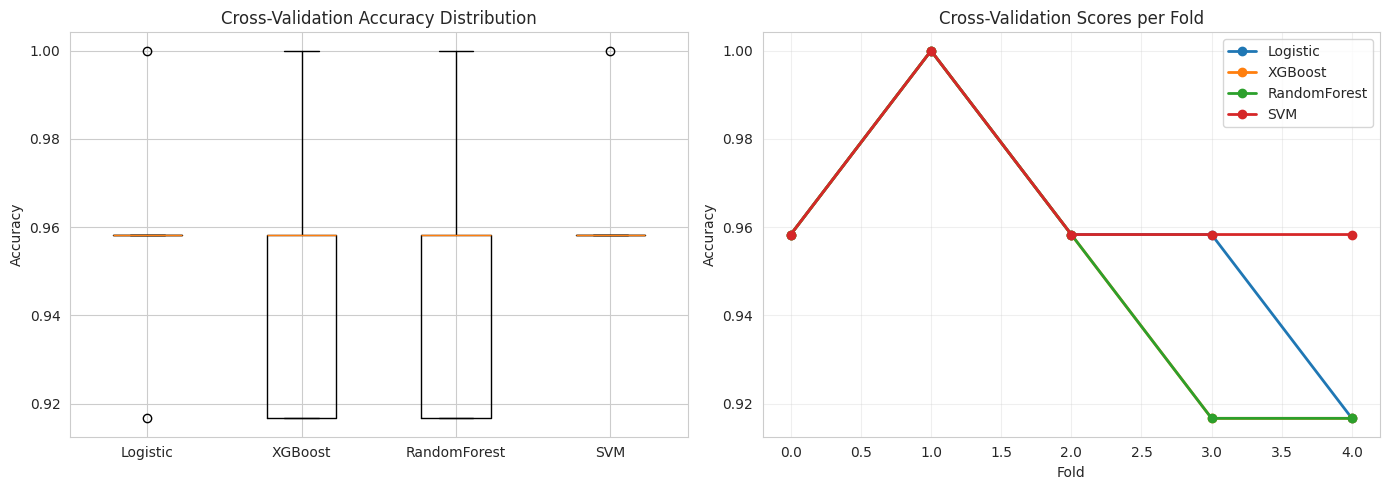

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_list = list(cv_results.keys())
axes[0].boxplot([cv_results[m] for m in models_list], labels=models_list)
axes[0].set_title('Cross-Validation Accuracy Distribution')
axes[0].set_ylabel('Accuracy')

x = np.arange(len(cv_results[models_list[0]]))
for m in models_list:
    axes[1].plot(x, cv_results[m], marker='o', label=m, linewidth=2)
axes[1].set_title('Cross-Validation Scores per Fold')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Grid Search Hyperparameter Tuning

In [14]:
# Logistic Regression Grid Search
log_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs'],
    'max_iter': [1000, 2000]
}

with mlflow.start_run(run_name='gridsearch_logistic'):
    log_grid = GridSearchCV(
        LogisticRegression(random_state=42),
        log_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    log_grid.fit(X_train_scaled, y_train)
    mlflow.log_params(log_grid.best_params_)
    mlflow.log_metric('best_cv_score', log_grid.best_score_)
    log_best = log_grid.best_estimator_
    y_pred = log_best.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred, average='macro')
    mlflow.log_metric('test_accuracy', test_acc)
    mlflow.log_metric('test_f1_macro', test_f1)
    print(f'Best Logistic Params: {log_grid.best_params_}')
    print(f'Best CV Score: {log_grid.best_score_:.4f}, Test Acc: {test_acc:.4f}, Test F1 Macro: {test_f1:.4f}')

# XGBoost Grid Search
xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0]
}

with mlflow.start_run(run_name='gridsearch_xgboost'):
    xgb_grid = GridSearchCV(
        XGBClassifier(eval_metric='mlogloss', random_state=42, verbosity=0),
        xgb_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    xgb_grid.fit(X_train, y_train)
    mlflow.log_params(xgb_grid.best_params_)
    mlflow.log_metric('best_cv_score', xgb_grid.best_score_)
    xgb_best = xgb_grid.best_estimator_
    y_pred = xgb_best.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred, average='macro')
    mlflow.log_metric('test_accuracy', test_acc)
    mlflow.log_metric('test_f1_macro', test_f1)
    print(f'Best XGBoost Params: {xgb_grid.best_params_}')
    print(f'Best CV Score: {xgb_grid.best_score_:.4f}, Test Acc: {test_acc:.4f}, Test F1 Macro: {test_f1:.4f}')

# RandomForest Grid Search
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

with mlflow.start_run(run_name='gridsearch_randomforest'):
    rf_grid = GridSearchCV(
        RandomForestClassifier(random_state=42),
        rf_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    rf_grid.fit(X_train, y_train)
    mlflow.log_params(rf_grid.best_params_)
    mlflow.log_metric('best_cv_score', rf_grid.best_score_)
    rf_best = rf_grid.best_estimator_
    y_pred = rf_best.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred, average='macro')
    mlflow.log_metric('test_accuracy', test_acc)
    mlflow.log_metric('test_f1_macro', test_f1)
    print(f'Best RandomForest Params: {rf_grid.best_params_}')
    print(f'Best CV Score: {rf_grid.best_score_:.4f}, Test Acc: {test_acc:.4f}, Test F1 Macro: {test_f1:.4f}')

# SVM Grid Search
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

with mlflow.start_run(run_name='gridsearch_svm'):
    svm_grid = GridSearchCV(
        SVC(probability=True, random_state=42, decision_function_shape='ovr'),
        svm_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    svm_grid.fit(X_train_scaled, y_train)
    mlflow.log_params(svm_grid.best_params_)
    mlflow.log_metric('best_cv_score', svm_grid.best_score_)
    svm_best = svm_grid.best_estimator_
    y_pred = svm_best.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred, average='macro')
    mlflow.log_metric('test_accuracy', test_acc)
    mlflow.log_metric('test_f1_macro', test_f1)
    print(f'Best SVM Params: {svm_grid.best_params_}')
    print(f'Best CV Score: {svm_grid.best_score_:.4f}, Test Acc: {test_acc:.4f}, Test F1 Macro: {test_f1:.4f}')

Best Logistic Params: {'C': 10, 'max_iter': 1000, 'solver': 'lbfgs'}
Best CV Score: 0.9667, Test Acc: 1.0000, Test F1 Macro: 1.0000
Best XGBoost Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
Best CV Score: 0.9583, Test Acc: 0.9667, Test F1 Macro: 0.9666
Best RandomForest Params: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 50}
Best CV Score: 0.9583, Test Acc: 0.9667, Test F1 Macro: 0.9666
Best SVM Params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Score: 0.9750, Test Acc: 0.9333, Test F1 Macro: 0.9333


## 5. Seed Experiments (Random State Sensitivity)

In [11]:
seeds = [0, 1, 42, 100, 999, 1234, 2024, 777, 314, 123]
seed_results = {m: [] for m in models.keys()}

for seed in seeds:
    # Logistic
    with mlflow.start_run(run_name=f'seed_logistic_{seed}'):
        m = LogisticRegression(max_iter=1000, random_state=seed)
        m.fit(X_train_scaled, y_train)
        acc = accuracy_score(y_test, m.predict(X_test_scaled))
        seed_results['Logistic'].append(acc)
        mlflow.log_param('random_state', seed)
        mlflow.log_metric('accuracy', acc)
    
    # XGBoost
    with mlflow.start_run(run_name=f'seed_xgboost_{seed}'):
        m = XGBClassifier(eval_metric='mlogloss', random_state=seed, verbosity=0)
        m.fit(X_train, y_train)
        acc = accuracy_score(y_test, m.predict(X_test))
        seed_results['XGBoost'].append(acc)
        mlflow.log_param('random_state', seed)
        mlflow.log_metric('accuracy', acc)
    
    # RandomForest
    with mlflow.start_run(run_name=f'seed_randomforest_{seed}'):
        m = RandomForestClassifier(random_state=seed)
        m.fit(X_train, y_train)
        acc = accuracy_score(y_test, m.predict(X_test))
        seed_results['RandomForest'].append(acc)
        mlflow.log_param('random_state', seed)
        mlflow.log_metric('accuracy', acc)
    
    # SVM
    with mlflow.start_run(run_name=f'seed_svm_{seed}'):
        m = SVC(probability=True, random_state=seed, decision_function_shape='ovr')
        m.fit(X_train_scaled, y_train)
        acc = accuracy_score(y_test, m.predict(X_test_scaled))
        seed_results['SVM'].append(acc)
        mlflow.log_param('random_state', seed)
        mlflow.log_metric('accuracy', acc)

seed_df = pd.DataFrame({'Seed': seeds, **seed_results})
print('Results per seed:')
print(seed_df.to_string(index=False))
for m in models.keys():
    print(f"{m:15s} - Mean: {np.mean(seed_results[m]):.4f}, Std: {np.std(seed_results[m]):.4f}")

Results per seed:
 Seed  Logistic  XGBoost  RandomForest      SVM
    0  0.933333 0.933333      0.933333 0.966667
    1  0.933333 0.933333      0.966667 0.966667
   42  0.933333 0.933333      0.900000 0.966667
  100  0.933333 0.933333      0.933333 0.966667
  999  0.933333 0.933333      0.900000 0.966667
 1234  0.933333 0.933333      0.966667 0.966667
 2024  0.933333 0.933333      0.933333 0.966667
  777  0.933333 0.933333      0.966667 0.966667
  314  0.933333 0.933333      0.933333 0.966667
  123  0.933333 0.933333      0.933333 0.966667
Logistic        - Mean: 0.9333, Std: 0.0000
XGBoost         - Mean: 0.9333, Std: 0.0000
RandomForest    - Mean: 0.9367, Std: 0.0233
SVM             - Mean: 0.9667, Std: 0.0000


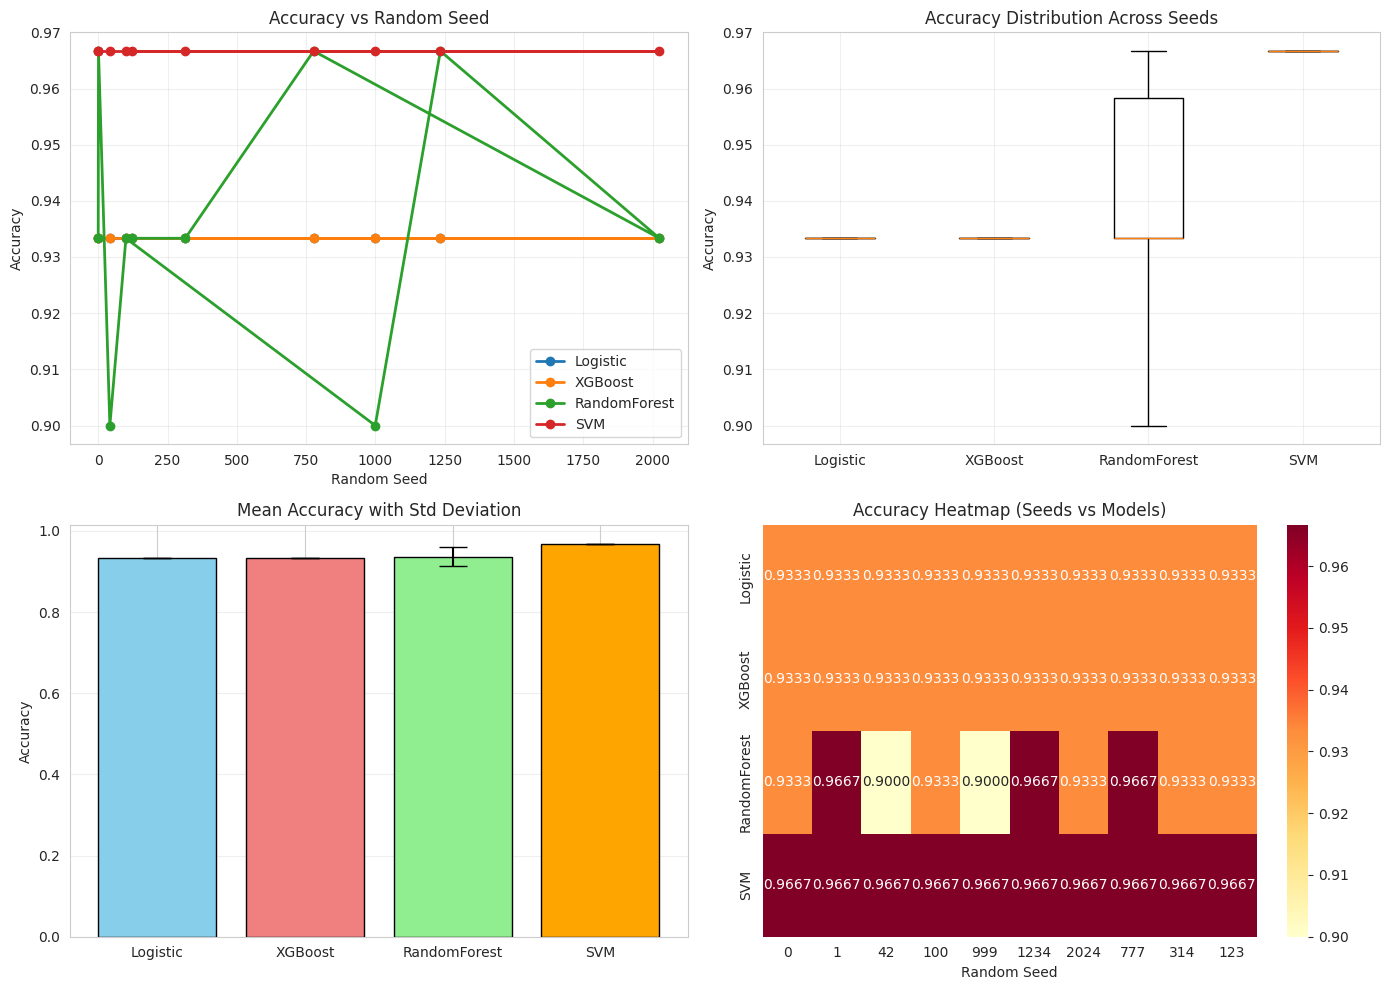

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Accuracy vs Seed
for m in models.keys():
    axes[0,0].plot(seeds, seed_results[m], marker='o', label=m, linewidth=2)
axes[0,0].set_title('Accuracy vs Random Seed')
axes[0,0].set_xlabel('Random Seed')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Boxplot
axes[0,1].boxplot([seed_results[m] for m in models.keys()], labels=models.keys())
axes[0,1].set_title('Accuracy Distribution Across Seeds')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Bar chart with std
means = [np.mean(seed_results[m]) for m in models.keys()]
stds = [np.std(seed_results[m]) for m in models.keys()]
axes[1,0].bar(models.keys(), means, yerr=stds, capsize=10, color=['skyblue', 'lightcoral', 'lightgreen', 'orange'], edgecolor='black')
axes[1,0].set_title('Mean Accuracy with Std Deviation')
axes[1,0].set_ylabel('Accuracy')
axes[1,0].grid(True, alpha=0.3, axis='y')

# Plot 4: Heatmap of seed results
seed_matrix = np.array([seed_results[m] for m in models.keys()])
sns.heatmap(seed_matrix, annot=True, fmt='.4f', cmap='YlOrRd', xticklabels=seeds, yticklabels=models.keys(), ax=axes[1,1])
axes[1,1].set_title('Accuracy Heatmap (Seeds vs Models)')
axes[1,1].set_xlabel('Random Seed')

plt.tight_layout()
plt.show()

## 6. Optuna Hyperparameter Optimization

In [15]:
def objective_logistic(trial):
    params = {
        'C': trial.suggest_float('C', 1e-3, 100, log=True),
        'solver': trial.suggest_categorical('solver', [ 'lbfgs', 'saga']),
        'max_iter': trial.suggest_int('max_iter', 1000, 5000),
        'random_state': 42
    }
    model = LogisticRegression(**params)
    score = cross_val_score(model, X_train_scaled, y_train, cv=3, scoring='accuracy').mean()
    return score

with mlflow.start_run(run_name='optuna_logistic'):
    study_log = optuna.create_study(direction='maximize')
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study_log.optimize(objective_logistic, n_trials=30)
    mlflow.log_params(study_log.best_params)
    mlflow.log_metric('best_cv_score', study_log.best_value)
    print(f'Best Logistic Params: {study_log.best_params}')
    print(f'Best CV Score: {study_log.best_value:.4f}')
    log_optuna = LogisticRegression(**study_log.best_params)
    log_optuna.fit(X_train_scaled, y_train)
    test_acc = accuracy_score(y_test, log_optuna.predict(X_test_scaled))
    test_f1 = f1_score(y_test, log_optuna.predict(X_test_scaled), average='macro')
    mlflow.log_metric('test_accuracy', test_acc)
    mlflow.log_metric('test_f1_macro', test_f1)
    print(f'Test Accuracy: {test_acc:.4f}, Test F1 Macro: {test_f1:.4f}')

Best Logistic Params: {'C': 1.3319923702880494, 'solver': 'lbfgs', 'max_iter': 2549}
Best CV Score: 0.9583
Test Accuracy: 0.9667, Test F1 Macro: 0.9666


In [16]:
def objective_xgboost(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'eval_metric': 'mlogloss',
        'random_state': 42,
        'verbosity': 0
    }
    model = XGBClassifier(**params)
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()
    return score

with mlflow.start_run(run_name='optuna_xgboost'):
    study_xgb = optuna.create_study(direction='maximize')
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study_xgb.optimize(objective_xgboost, n_trials=50)
    mlflow.log_params(study_xgb.best_params)
    mlflow.log_metric('best_cv_score', study_xgb.best_value)
    print(f'Best XGBoost Params: {study_xgb.best_params}')
    print(f'Best CV Score: {study_xgb.best_value:.4f}')
    xgb_optuna = XGBClassifier(**study_xgb.best_params)
    xgb_optuna.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, xgb_optuna.predict(X_test))
    test_f1 = f1_score(y_test, xgb_optuna.predict(X_test), average='macro')
    mlflow.log_metric('test_accuracy', test_acc)
    mlflow.log_metric('test_f1_macro', test_f1)
    print(f'Test Accuracy: {test_acc:.4f}, Test F1 Macro: {test_f1:.4f}')

Best XGBoost Params: {'n_estimators': 144, 'max_depth': 10, 'learning_rate': 0.0404518762094765, 'subsample': 0.6059854303365111, 'colsample_bytree': 0.60005980026572, 'min_child_weight': 2}
Best CV Score: 0.9750
Test Accuracy: 0.9333, Test F1 Macro: 0.9333


In [17]:
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'random_state': 42
    }
    model = RandomForestClassifier(**params)
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()
    return score

with mlflow.start_run(run_name='optuna_randomforest'):
    study_rf = optuna.create_study(direction='maximize')
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study_rf.optimize(objective_rf, n_trials=40)
    mlflow.log_params(study_rf.best_params)
    mlflow.log_metric('best_cv_score', study_rf.best_value)
    print(f'Best RandomForest Params: {study_rf.best_params}')
    print(f'Best CV Score: {study_rf.best_value:.4f}')
    rf_optuna = RandomForestClassifier(**study_rf.best_params)
    rf_optuna.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, rf_optuna.predict(X_test))
    test_f1 = f1_score(y_test, rf_optuna.predict(X_test), average='macro')
    mlflow.log_metric('test_accuracy', test_acc)
    mlflow.log_metric('test_f1_macro', test_f1)
    print(f'Test Accuracy: {test_acc:.4f}, Test F1 Macro: {test_f1:.4f}')

Best RandomForest Params: {'n_estimators': 277, 'max_depth': 20, 'min_samples_split': 9, 'min_samples_leaf': 3}
Best CV Score: 0.9667
Test Accuracy: 0.9333, Test F1 Macro: 0.9333


In [18]:
def objective_svm(trial):
    kernel = trial.suggest_categorical('kernel', ['linear', 'rbf'])
    params = {
        'C': trial.suggest_float('C', 1e-3, 100, log=True),
        'kernel': kernel,
        'random_state': 42,
        'decision_function_shape': 'ovr'
    }
    if kernel == 'rbf':
        params['gamma'] = trial.suggest_categorical('gamma', ['scale', 'auto'])
    model = SVC(probability=True, **params)
    score = cross_val_score(model, X_train_scaled, y_train, cv=3, scoring='accuracy').mean()
    return score

with mlflow.start_run(run_name='optuna_svm'):
    study_svm = optuna.create_study(direction='maximize')
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study_svm.optimize(objective_svm, n_trials=40)
    mlflow.log_params(study_svm.best_params)
    mlflow.log_metric('best_cv_score', study_svm.best_value)
    print(f'Best SVM Params: {study_svm.best_params}')
    print(f'Best CV Score: {study_svm.best_value:.4f}')
    svm_optuna = SVC(probability=True, **study_svm.best_params)
    svm_optuna.fit(X_train_scaled, y_train)
    test_acc = accuracy_score(y_test, svm_optuna.predict(X_test_scaled))
    test_f1 = f1_score(y_test, svm_optuna.predict(X_test_scaled), average='macro')
    mlflow.log_metric('test_accuracy', test_acc)
    mlflow.log_metric('test_f1_macro', test_f1)
    print(f'Test Accuracy: {test_acc:.4f}, Test F1 Macro: {test_f1:.4f}')

Best SVM Params: {'kernel': 'linear', 'C': 1.2552045585581681}
Best CV Score: 0.9750
Test Accuracy: 0.9667, Test F1 Macro: 0.9666


## 7. Model Comparison & Final Evaluation

Model Performance Summary:
       Model  Baseline Acc  Baseline F1 Macro  CV Mean Acc  Seed Mean Acc
    Logistic      0.933333           0.933333     0.958333       0.933333
     XGBoost      0.933333           0.933333     0.950000       0.933333
RandomForest      0.900000           0.899749     0.950000       0.936667
         SVM      0.966667           0.966583     0.966667       0.966667


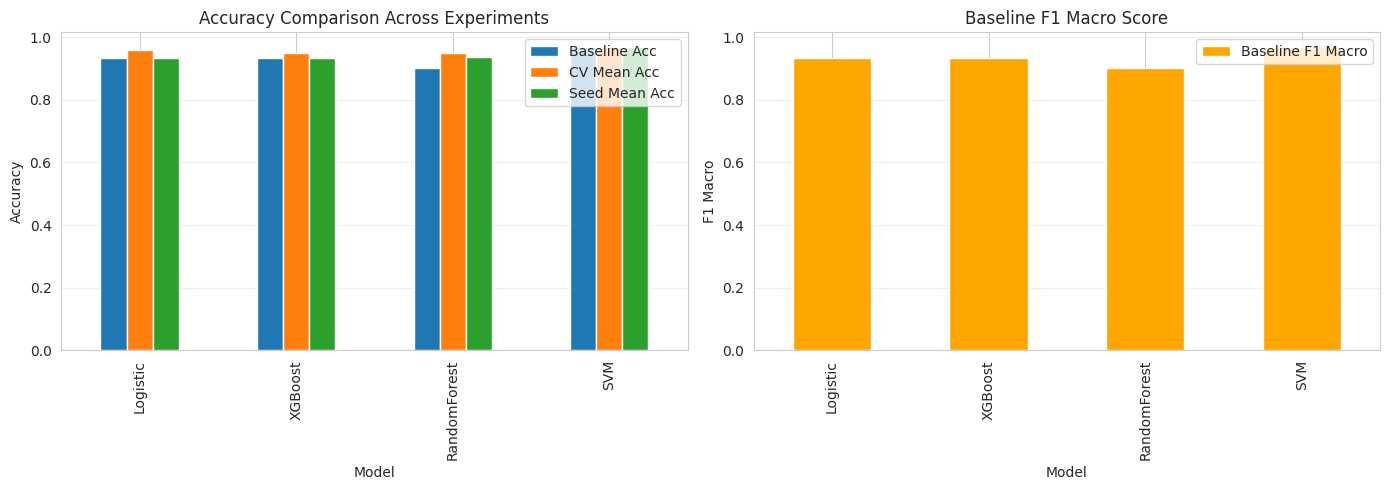

In [19]:
# Compile results
comparison = pd.DataFrame({
    'Model': list(models.keys()),
    'Baseline Acc': [baseline_results[m]['accuracy'] for m in models.keys()],
    'Baseline F1 Macro': [baseline_results[m]['f1_macro'] for m in models.keys()],
    'CV Mean Acc': [cv_results[m].mean() for m in models.keys()],
    'Seed Mean Acc': [np.mean(seed_results[m]) for m in models.keys()],
})

print('Model Performance Summary:')
print(comparison.to_string(index=False))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
comparison.set_index('Model')[['Baseline Acc', 'CV Mean Acc', 'Seed Mean Acc']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Accuracy Comparison Across Experiments')
axes[0].set_ylabel('Accuracy')
axes[0].grid(True, alpha=0.3, axis='y')

comparison.set_index('Model')[['Baseline F1 Macro']].plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Baseline F1 Macro Score')
axes[1].set_ylabel('F1 Macro')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()